In [11]:
!pip install --upgrade yfinance
import yfinance as yf
yf.download("TSLA", '2015-01-01', '2025-01-01')

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500
...,...,...,...,...,...
2024-12-24,462.279999,462.779999,435.140015,435.899994,59551800
2024-12-26,454.130005,465.329987,451.019989,465.160004,76366400


In [12]:
import yfinance as yf
yf.download("TSLA", '2015-01-01', '2025-01-01')

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500
...,...,...,...,...,...
2024-12-24,462.279999,462.779999,435.140015,435.899994,59551800
2024-12-26,454.130005,465.329987,451.019989,465.160004,76366400


In [13]:
from statsmodels.tsa.stattools import adfuller
import numpy as np
import pandas as pd
from numpy import log
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

In [14]:
import yfinance as yf
start = '2018-10-1'
end = '2024-12-31'
series = yf.download("TSLA", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [15]:
print(len(series))

1572


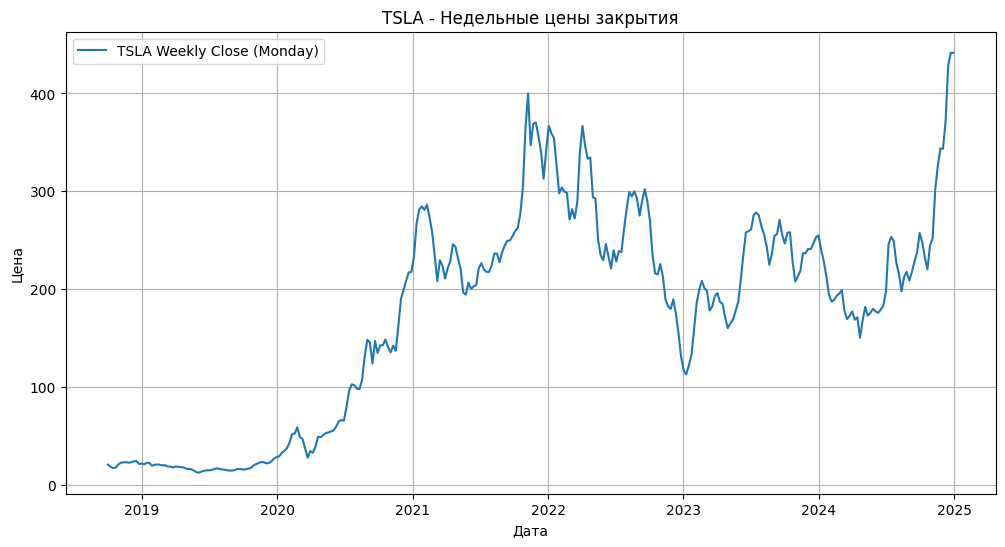

In [16]:
weekly_close = series['Close'].resample('W-MON').mean()
# Строим график
plt.figure(figsize=(12, 6))
plt.plot(weekly_close, label='TSLA Weekly Close (Monday)')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.title('TSLA - Недельные цены закрытия')
plt.legend()
plt.grid()
plt.show()

График показывает недельные средние цены закрытия акций Tesla (TSLA), рассчитанные по понедельникам, за период с конца 2018 года по начало 2025 года.

До конца 2019 года цена акций держалась на уровне около 20–40 долларов.
С 2020 года начинается стремительный рост: к началу 2021 года цена поднимается выше 200 долларов.
На пике в конце 2021 – начале 2022 года цена приближается к 400 долларам.
Затем наблюдается волатильность: колебания и снижение в течение 2022–2023 годов.
В 2024 году — новый рост, и к началу 2025 года цена достигает рекордного уровня более 450 долларов.

<ipython-input-17-930b1db7b87b>:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = series['Close'].resample('M').mean()


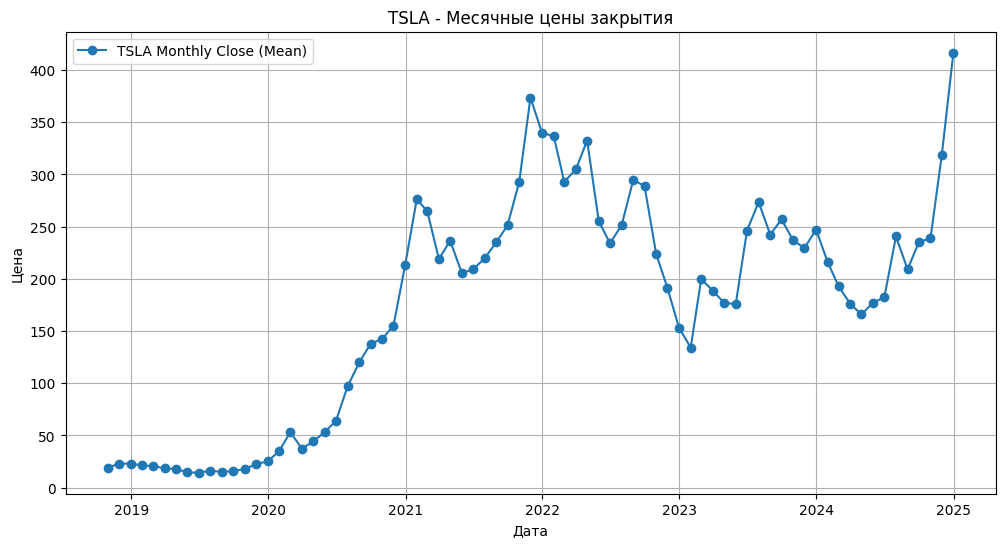

In [17]:
monthly_close = series['Close'].resample('M').mean()

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(monthly_close, label='TSLA Monthly Close (Mean)', marker='o')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.title('TSLA - Месячные цены закрытия')
plt.legend()
plt.grid()
plt.show()

Этот график отображает средние месячные цены закрытия акций Tesla (TSLA) за период с конца 2018 года по начало 2025 года.

<ipython-input-19-73055bc70c20>:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = series['Close'].resample('M').mean()


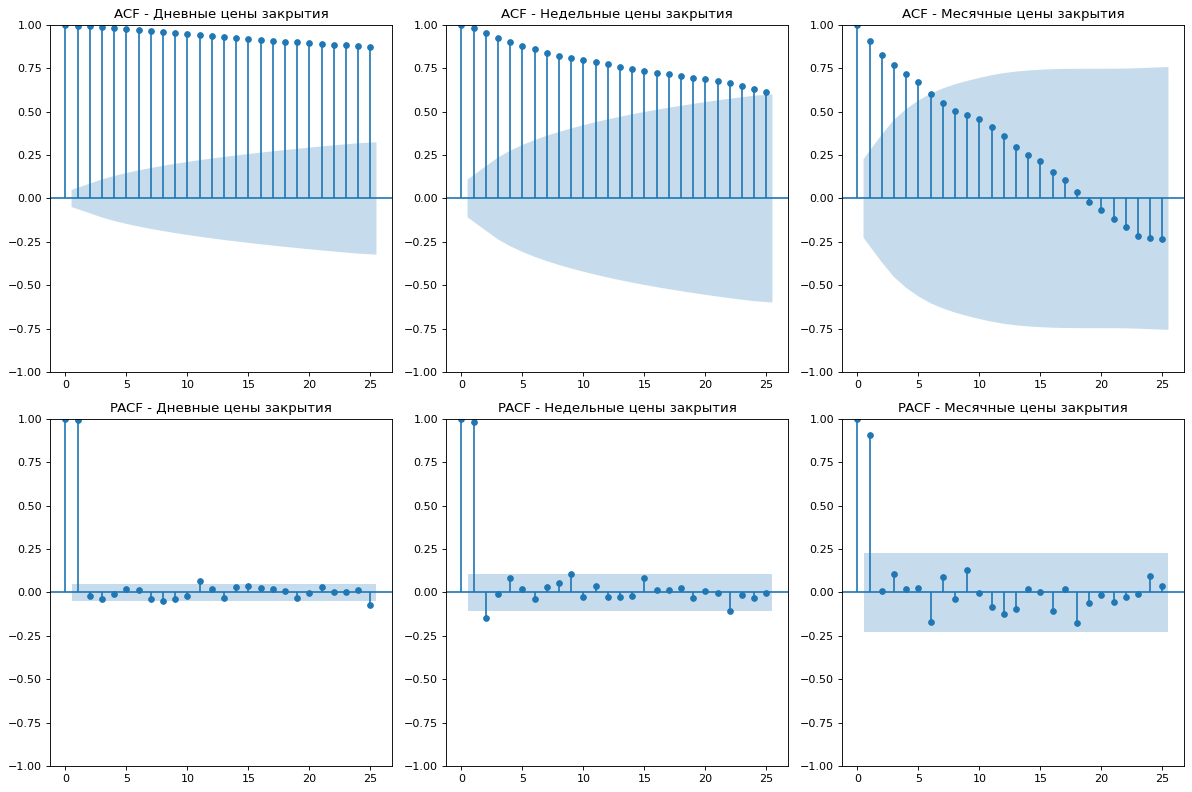

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Создаем подграфики
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=False, dpi=80)

# Дневная периодичность
plot_acf(series['Close'], ax=axes[0, 0], lags=25)
plot_pacf(series['Close'], ax=axes[1, 0], lags=25, method="ywm")

# Недельная периодичность
weekly_close = series['Close'].resample('W-MON').mean()
plot_acf(weekly_close, ax=axes[0, 1], lags=25)
plot_pacf(weekly_close, ax=axes[1, 1], lags=25, method="ywm")

# Месячная периодичность
monthly_close = series['Close'].resample('M').mean()
plot_acf(monthly_close, ax=axes[0, 2], lags=25)
plot_pacf(monthly_close, ax=axes[1, 2], lags=25, method="ywm")

# Улучшаем внешний вид графиков
axes[0, 0].set_title("ACF - Дневные цены закрытия")
axes[1, 0].set_title("PACF - Дневные цены закрытия")
axes[0, 1].set_title("ACF - Недельные цены закрытия")
axes[1, 1].set_title("PACF - Недельные цены закрытия")
axes[0, 2].set_title("ACF - Месячные цены закрытия")
axes[1, 2].set_title("PACF - Месячные цены закрытия")

plt.tight_layout()
plt.show()

На изображении показаны графики автокорреляции (ACF) и частичной автокорреляции (PACF) для цен закрытия акций Tesla (TSLA) на трех уровнях агрегации: дневном, недельном и месячном.

Все ряды имеют автокорреляции и нуждаются в дифференцировании для анализа ARIMA-моделями.

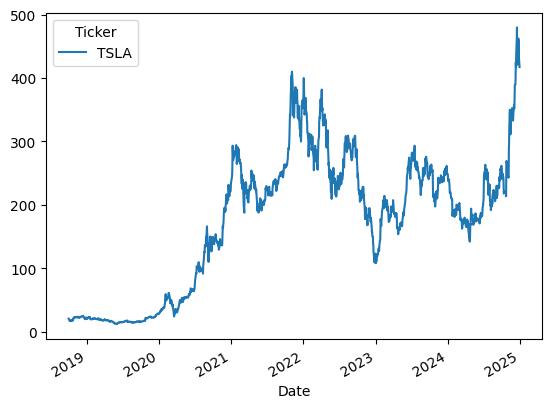

In [20]:
series['Close'].plot()
plt.show()

In [21]:
# Дневная периодичность
adf_test_d = adfuller(series['Close'].dropna())
print('Дневная периодичность:')
print('ADF-statistic: %f' % adf_test_d[0])
print('p-value: %f' % adf_test_d[1])
print('-' * 40)

# Недельная периодичность
adf_test_w = adfuller(series['Close'].resample('W-MON').mean().dropna())
print('Недельная периодичность:')
print('ADF-statistic: %f' % adf_test_w[0])
print('p-value: %f' % adf_test_w[1])
print('-' * 40)

# Месячная периодичность
adf_test_m = adfuller(series['Close'].resample('M').mean().dropna())
print('Месячная периодичность:')
print('ADF-statistic: %f' % adf_test_m[0])
print('p-value: %f' % adf_test_m[1])

Дневная периодичность:
ADF-statistic: -1.208792
p-value: 0.669802
----------------------------------------
Недельная периодичность:
ADF-statistic: -1.068711
p-value: 0.727387
----------------------------------------
Месячная периодичность:
ADF-statistic: -0.978136
p-value: 0.761155


<ipython-input-21-055c2d8d1c65>:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  adf_test_m = adfuller(series['Close'].resample('M').mean().dropna())


На изображении представлены результаты теста Дики-Фуллера (ADF) для проверки стационарности временного ряда цен закрытия акций Tesla (TSLA) на трех уровнях агрегации: дневной, недельной и месячной.

Во всех трёх случаях p-value значительно превышает 0.05, что указывает на наличие тренда или сезонности в ряде. Это подтверждает выводы, сделанные ранее на основе графиков ACF/PACF.

In [22]:
#для разностей ряда:
#дневная:
adf_test_dd = adfuller(series.Close.diff().dropna())
print('ADF-statistic: %f' % adf_test_dd[0])
print('p-value: %f' % adf_test_dd[1])

#недельная:
adf_test_wd = adfuller(series.Close.resample('W-MON').mean().diff().dropna())
print('ADF-statistic: %f' % adf_test_wd[0])
print('p-value: %f' % adf_test_wd[1])

#месячная:
adf_test_md = adfuller(series.Close.resample('M').mean().diff().dropna())
print('ADF-statistic: %f' % adf_test_md[0])
print('p-value: %f' % adf_test_md[1])

ADF-statistic: -7.049577
p-value: 0.000000
ADF-statistic: -12.927872
p-value: 0.000000
ADF-statistic: -6.436834
p-value: 0.000000


<ipython-input-22-15987f8d4528>:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  adf_test_md = adfuller(series.Close.resample('M').mean().diff().dropna())


Ряды стали стационарными после первого дифференцирования.

<ipython-input-23-fcb0d90673af>:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plot_acf(series.Close.resample('M').mean().diff().dropna(), ax=axes[0, 2], lags=25, marker=None)
<ipython-input-23-fcb0d90673af>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plot_pacf(series.Close.resample('M').mean().diff().dropna(), ax=axes[1, 2], lags=25, marker=None)


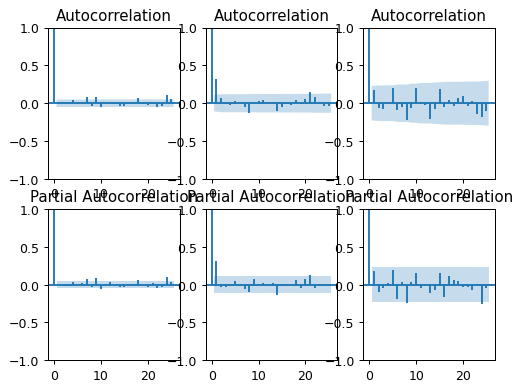

In [23]:
fig, axes = plt.subplots(2, 3, sharex=False, dpi=90)
plot_acf(series.Close.diff().dropna(), ax=axes[0, 0], lags=25, marker=None)
plot_pacf(series.Close.diff().dropna(), ax=axes[1, 0], lags=25, marker=None)
plot_acf(series.Close.resample('W-MON').mean().diff().dropna(), ax=axes[0, 1], lags=25, marker=None)
plot_pacf(series.Close.resample('W-MON').mean().diff().dropna(), ax=axes[1, 1], lags=25, marker=None)
plot_acf(series.Close.resample('M').mean().diff().dropna(), ax=axes[0, 2], lags=25, marker=None)
plot_pacf(series.Close.resample('M').mean().diff().dropna(), ax=axes[1, 2], lags=25, marker=None)
plt.show()

Построил графики ACF и PACF для разностей рядов цен закрытия акций Tesla с дневной, недельной и месячной периодичностью. Это важный шаг для выбора параметров p и q модели ARIMA.

<ipython-input-24-b6b919b61f13>:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  axes[0].plot(series.Close.resample('M').mean()); axes[0].set_title('Original series, Monthly')
<ipython-input-24-b6b919b61f13>:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  axes[1].plot(series.Close.resample('M').mean().diff().dropna()); axes[1].set_title('1st differencing order')


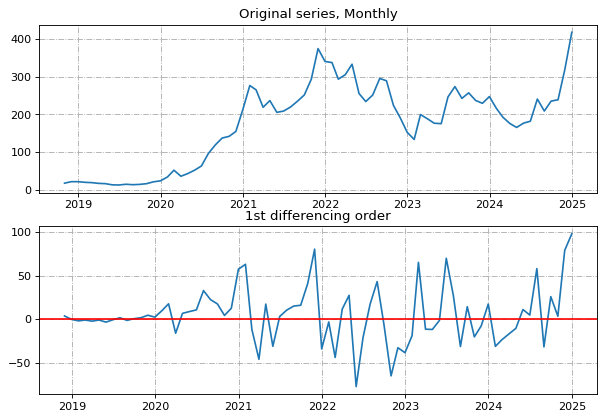

In [24]:
#Исследуем разности 1го порядка
fig, axes = plt.subplots(2, 1, figsize=(9,6), dpi= 80)
axes[0].plot(series.Close.resample('M').mean()); axes[0].set_title('Original series, Monthly')
axes[0].grid(linestyle='-.')
axes[1].plot(series.Close.resample('M').mean().diff().dropna()); axes[1].set_title('1st differencing order')
axes[1].axhline(y=0, color='r')
axes[1].grid(linestyle='-.')
plt.show()

Исходный временной ряд и его разности первого порядка для месячных средних цен закрытия TSLA.

Нижний график показывает разности первого пордка. Ряд колеблется вокруг нуля, можно заметить, что ряд переходит ближе к стационарному.

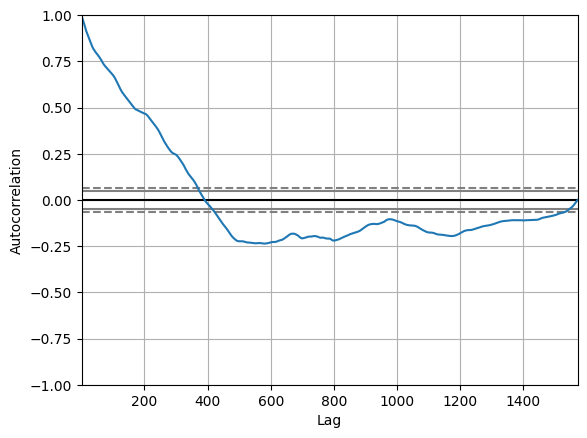

In [25]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(series.Close)
plt.show()

Исходный ряд не является стационарным.

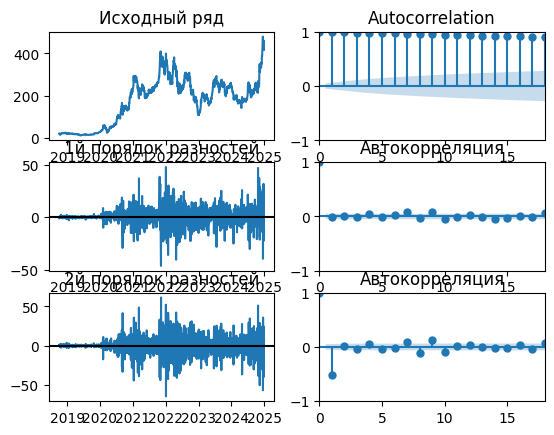

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, sharex=False)
axes[0, 0].plot(series.Close); axes[0, 0].set_title('Исходный ряд')
plot_acf(series.Close, ax=axes[0, 1])
axes[0,1].set_xlim(xmin=0, xmax=18)

axes[1, 0].plot(series.Close.diff()); axes[1, 0].set_title('1й порядок разностей')
plot_acf(series.Close.diff().dropna(), ax=axes[1, 1]); axes[1, 1].set_title('Автокорреляция')
axes[1, 0].axhline(y=0, color='black')
axes[1,1].set_xlim(xmin=0, xmax=18)

axes[2, 0].plot(series.Close.diff().diff()); axes[2, 0].set_title('2й порядок разностей')
plot_acf(series.Close.diff().diff().dropna(), ax=axes[2, 1]); axes[2, 1].set_title('Автокорреляция')
axes[2, 0].axhline(y=0, color='black')
axes[2,1].set_xlim(xmin=0, xmax=18)
plt.show()

**Первая строка: исходный ряд**

График слева: чёткий восходящий тренд.
ACF справа: автокорреляция очень высокая на всех лагах — нестационарный ряд.

**Вторая строка: разности первого порядка**

Ряд визуально колеблется вокруг нуля — признак стационарности.
ACF быстро спадает, только первый лаг значим, хорошо для ARIMA с d=1.

**Третья строка: разности второго порядка**

Ряд выглядит более шумным, но без явных паттернов.
ACF почти полностью внутри доверительного интервала.

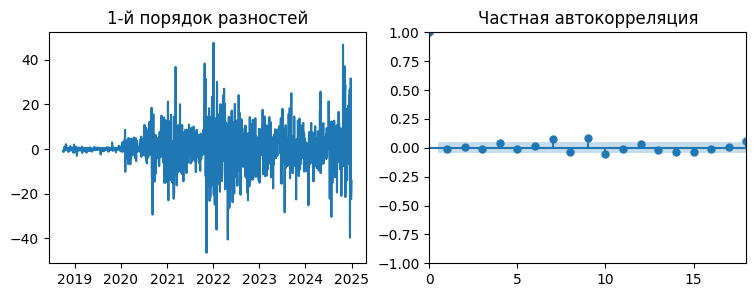

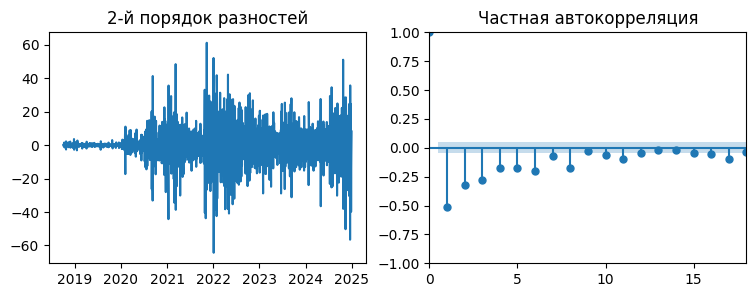

In [27]:
# 1-й порядок разностей
plt.rcParams.update({'figure.figsize': (9, 3)})
fig, axes = plt.subplots(1, 2, sharex=False)

axes[0].plot(series['Close'].diff())
axes[0].set_title('1-й порядок разностей')

axes[1].set_xlim(0, 18)  # Исправлено обращение к оси
plot_pacf(series['Close'].diff().dropna(), ax=axes[1], method="ywm")
axes[1].set_title('Частная автокорреляция')

plt.show()

# 2-й порядок разностей
plt.rcParams.update({'figure.figsize': (9, 3)})
fig, axes = plt.subplots(1, 2, sharex=False)

axes[0].plot(series['Close'].diff().diff())
axes[0].set_title('2-й порядок разностей')

axes[1].set_xlim(0, 18)  # Исправлено обращение к оси
plot_pacf(series['Close'].diff().diff().dropna(), ax=axes[1], method="ywm")
axes[1].set_title('Частная автокорреляция')

plt.show()

**1-й порядок разностей:**

Слева: разности выглядят как стационарный ряд — колебания вокруг нуля, без тренда.

Справа (PACF): только первый лаг значимо выделяется, остальные — в пределах доверительного интервала.


**2-й порядок разностей:**

Слева: более сильные колебания, шум усиливается — нет явной пользы.

Справа (PACF): много лагов оказываются значимыми, но структура хаотична — может быть признаком переобработки.

<Figure size 900x300 with 0 Axes>

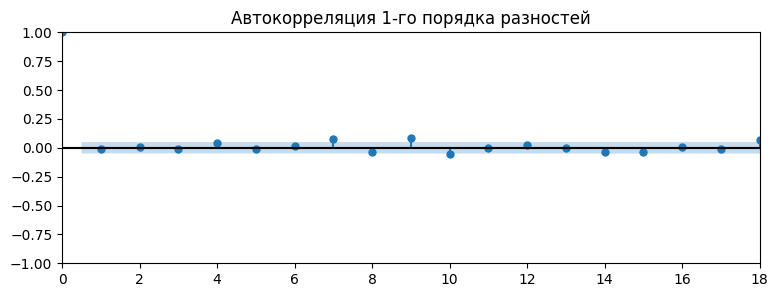

<Figure size 900x300 with 0 Axes>

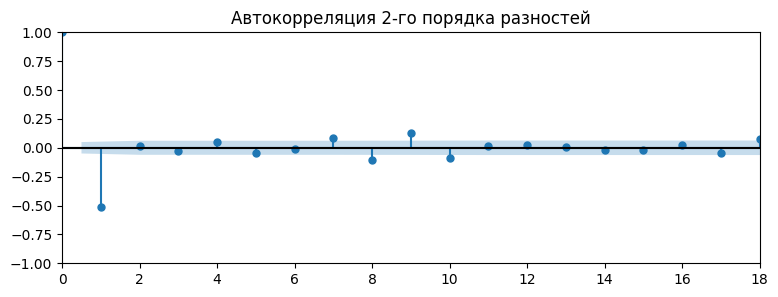

In [28]:
# Автокорреляция 1-го порядка разностей
plt.figure(figsize=(9, 3))
plot_acf(series['Close'].diff().dropna())
plt.title('Автокорреляция 1-го порядка разностей')
plt.axhline(y=0, color='black')

# Устанавливаем пределы оси X
plt.gca().set_xlim(0, 18)

plt.show()

# Автокорреляция 2-го порядка разностей
plt.figure(figsize=(9, 3))
plot_acf(series['Close'].diff().diff().dropna())
plt.title('Автокорреляция 2-го порядка разностей')
plt.axhline(y=0, color='black')

# Устанавливаем пределы оси X
plt.gca().set_xlim(0, 18)

plt.show()

Оптимальный порядок дифференцирования: d = 1

<ipython-input-29-3c8c50fc8387>:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('predicted=%f, expected=%f' % (yhat, obs))


predicted=224.839373, expected=234.860001
predicted=234.708229, expected=244.399994
predicted=244.435500, expected=249.830002
predicted=250.032134, expected=258.709991
predicted=259.138469, expected=256.790009
predicted=257.531214, expected=255.899994
predicted=256.202648, expected=260.540009
predicted=260.814734, expected=274.450012
predicted=273.923880, expected=259.459991
predicted=260.232569, expected=264.609985
predicted=264.531278, expected=256.600006
predicted=257.672976, expected=241.050003
predicted=240.611295, expected=250.210007
predicted=249.842897, expected=256.239990
predicted=255.565096, expected=257.500000
predicted=256.883446, expected=261.769989
predicted=262.259433, expected=279.820007
predicted=279.484643, expected=282.480011
predicted=282.753803, expected=276.540009
predicted=277.203390, expected=274.429993
predicted=275.341094, expected=269.609985
predicted=269.610263, expected=269.790009
predicted=269.351409, expected=271.989990
predicted=271.828532, expected=277

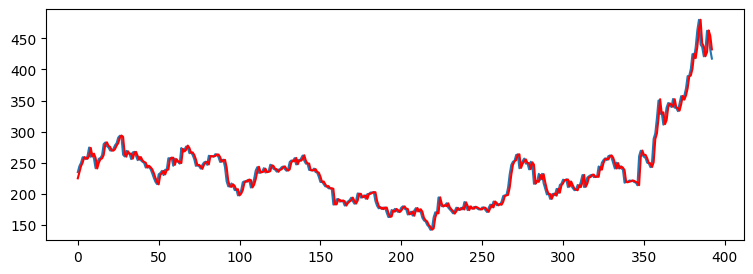

In [29]:
X = series.Close.values
size = int(len(X) * 0.75)
train, test = X[0:size], X[size:len(X)]
series.index = series.index.to_period('d')
historical = [x for x in train]
predictions = list()

for t in range(len(test)):
 model = ARIMA(historical, order=(5,1,0))
 model_fit = model.fit()
 output = model_fit.forecast()
 yhat = output[0]
 predictions.append(yhat)
 obs = test[t]
 historical.append(obs)
 print('predicted=%f, expected=%f' % (yhat, obs))

# получим прогноз
from sklearn.metrics import mean_squared_error
import math
rmse = math.sqrt(mean_squared_error(test, predictions))
print('Тест RMSE: %.3f' % rmse)

# выведем результаты на графике
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1571
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -5471.648
Date:                Wed, 02 Apr 2025   AIC                          10955.296
Time:                        09:02:18   BIC                          10987.449
Sample:                             0   HQIC                         10967.246
                               - 1571                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0105      0.020     -0.533      0.594      -0.049       0.028
ar.L2          0.0053      0.017      0.317      0.751      -0.028       0.038
ar.L3         -0.0056      0.020     -0.275      0.7

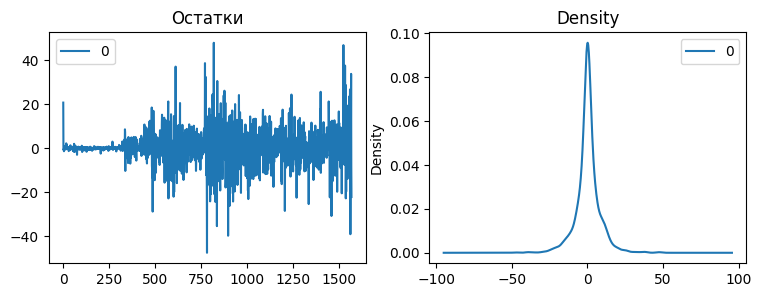

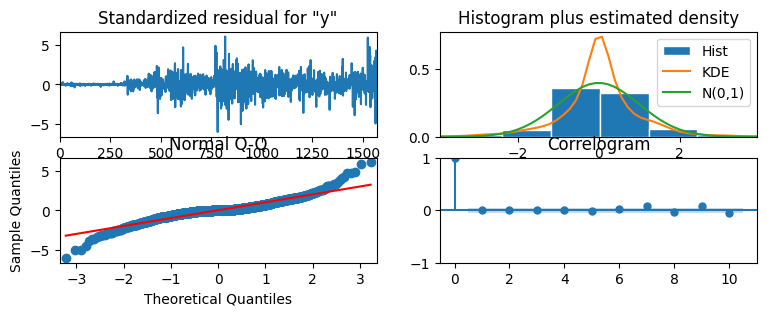

In [30]:
print(model.fit().summary())
residuals = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2)
residuals.plot(title="Остатки", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

model_fit.plot_diagnostics()
plt.show()

Остатки на графике выглядят как шум, но не идеально — видны всплески (возможно, гетероскедастичность).
График плотности (Density) и KDE — острые пики, возможны выбросы.
Q-Q plot (сравнение с нормальным распределением): сильные отклонения в хвостах ⇒ остатки не вполне нормальны.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

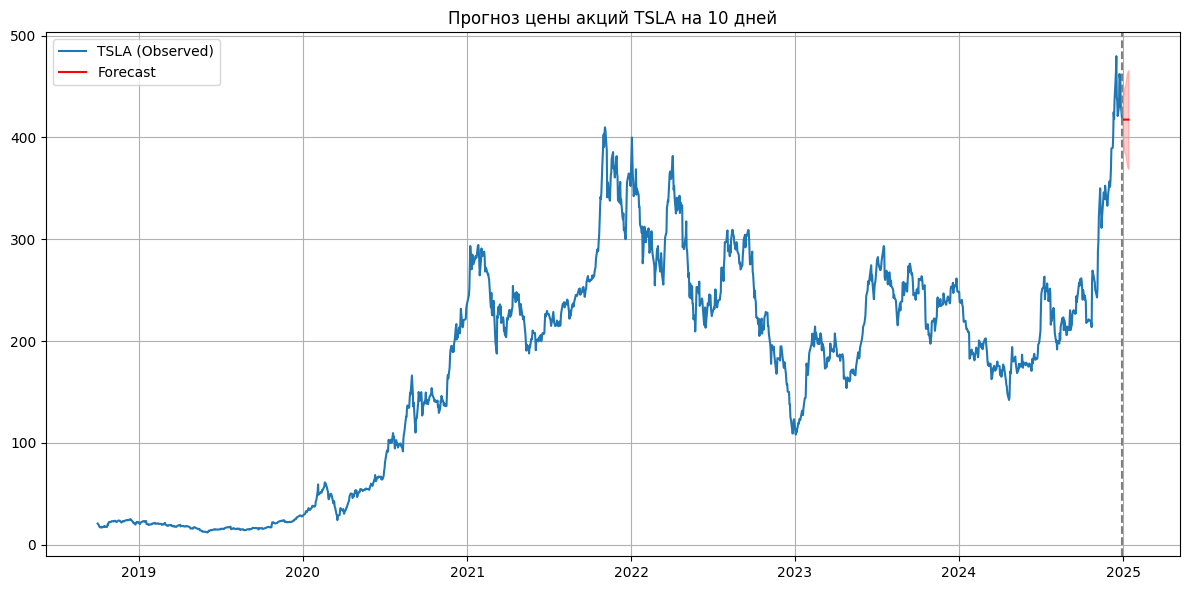

In [38]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd

# Убедимся, что индекс — даты
series.index = pd.to_datetime(series.index)

# Обучаем модель на series['Close'] с датами в индексе
model = ARIMA(series['Close'], order=(1, 1, 1))
model_fit = model.fit()

# Прогноз
forecast = model_fit.get_forecast(steps=10)
forecast_mean = forecast.predicted_mean
forecast_conf = forecast.conf_int()

# Используем индекс прогнозируемых значений (уже правильный)
forecast_index = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1), periods=10, freq='B')
forecast_mean.index = forecast_index
forecast_conf.index = forecast_index

# График
plt.figure(figsize=(12, 6))
plt.plot(series['Close'], label='TSLA (Observed)')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_conf.index,
                 forecast_conf.iloc[:, 0],
                 forecast_conf.iloc[:, 1],
                 color='red', alpha=0.2)
plt.axvline(series.index[-1], color='gray', linestyle='--')
plt.title('Прогноз цены акций TSLA на 10 дней')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Прогноз получился реалистичным и гладким, без переобучения.
Модель ARIMA(1,1,1) хорошо улавливает краткосрочный тренд.
Учитывая последние всплески цен, ARIMA прогнозирует умеренную стабилизацию, а не новый резкий рост или падение.